# Auto ARIMA Benchmark — smooth 1.0.9

Rerun of the auto-ARIMA comparison on M1 + M3 + Tourism (5,315 series) after the
backcasting rewrite on the `backcast-warmstart` branch. Same harness and metrics
as before: point accuracy (**RMSSE**), **computational time**, **scaled pinball**
loss and **calibration** at the 99 levels `seq(0.01, 0.99, 0.01)`. One fit per
series produces the point forecast and all 99 quantiles.

**Only the smooth rows were recomputed.** `AutoMSARIMA` with backcasting and with
optimal initialisation ran again on the current build; the competitor rows are
read from the saved arrays of the previous full run and carried into the tables
unchanged, since none of those packages changed. Every table carries a `Source`
column saying which run each row comes from, and no row mixes the two.

**Compared here**

| Method | Package |
|---|---|
| `AutoMSARIMA(initial="backcasting")` | smooth (rerun) |
| `AutoMSARIMA(initial="optimal")` | smooth (rerun) |
| `AutoARIMA` | statsforecast (saved) |
| `Arima(order=None, seasonal_order=None)` | skforecast (saved) |

**Still excluded**, for the reasons established in the previous notebook and
requantified below from the saved arrays: **sktime** `AutoARIMA` is an adapter
over `pmdarima.arima.AutoARIMA` and never fitted here; **pmdarima** `auto_arima`
leaves part of the sample unscored and costs an order of magnitude more time per
series; **aeon** `AutoARIMA` searches non-seasonal orders only and exposes no
quantile API.

In [1]:
import glob, os, subprocess, sys
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)
LEVELS = np.round(np.arange(0.01, 1.0, 0.01), 2)

HERE = os.getcwd()
PAPER = os.path.join(HERE, "smooth-paper")

SMOOTH = ["AutoMSARIMA Back", "AutoMSARIMA Opt"]
COMPETITORS = ["statsforecast AutoARIMA", "skforecast Arima"]
EXCLUDED = ["pmdarima auto_arima", "aeon AutoARIMA"]

## Versions

In [2]:
from importlib.metadata import version as pkg_version

print(f"python {sys.version.split()[0]}")
for _p in ("smooth", "numpy", "pandas", "statsforecast", "skforecast",
           "pmdarima", "aeon", "sktime", "fcompdata"):
    try:
        print(f"{_p:15s} v{pkg_version(_p)}")
    except Exception:
        print(f"{_p:15s} not installed")

print("\ngit branch / HEAD:")
for cmd in (["git", "rev-parse", "--abbrev-ref", "HEAD"], ["git", "log", "-1", "--format=%h %s"]):
    print("  " + subprocess.run(cmd, capture_output=True, text=True).stdout.strip())

python 3.14.4
smooth          v1.0.9
numpy           v2.3.5
pandas          v2.3.3
statsforecast   v2.1.1
skforecast      v0.23.0
pmdarima        v2.1.1
aeon            v1.5.0
sktime          v1.0.1
fcompdata       v0.1.4

git branch / HEAD:
  backcast-warmstart
  1ef21435 Open the v1.0.9 section in the Python NEWS


## Datasets

In [3]:
from fcompdata import M1, M3, Tourism

datasets = ([M1[k] for k in M1.keys()]
            + [M3[k] for k in M3.keys()]
            + [Tourism[k] for k in Tourism.keys()])
print(f"M1: {len(M1)}   M3: {len(M3)}   Tourism: {len(Tourism)}   total: {len(datasets)}")

M1: 1001   M3: 3003   Tourism: 1311   total: 5315


## Run or load

The smooth rows come from `smooth-paper/run_full_benchmark.py` restricted to the
`AutoMSARIMA` rows (`BENCH_KIND=arima BENCH_ONLY=automsarima`); set
`BENCH_RERUN_ARIMA=1` to recompute them here. The competitor rows are read from
the arrays of the last full run, which included every implementation.

In [4]:
if os.environ.get("BENCH_RERUN_ARIMA", "0") == "1":
    import multiprocessing
    workers = os.environ.get("BENCH_WORKERS", str(min(20, multiprocessing.cpu_count())))
    # BENCH_ONLY alone selects the two AutoMSARIMA rows and tags the output
    # "automsarima"; adding BENCH_KIND would tag it "arima" and shadow the
    # full-roster arrays that the competitor rows are read from.
    subprocess.run([sys.executable, "run_full_benchmark.py"], cwd=PAPER, check=True,
                   env=dict(os.environ, BENCH_ONLY="automsarima", BENCH_WORKERS=workers,
                            OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1",
                            MKL_NUM_THREADS="1"))


def newest(pattern):
    # Newest file matching `pattern` in this directory or in smooth-paper/.
    hits = glob.glob(os.path.join(HERE, pattern)) + glob.glob(os.path.join(PAPER, pattern))
    if not hits:
        raise FileNotFoundError(pattern)
    return sorted(hits, key=os.path.basename)[-1]


def load_run(stem):
    # A run is a point array, a dist array and the method names in array order.
    point_file = newest(f"*-benchmark-{stem}-point.npy")
    dist_file = newest(f"*-benchmark-{stem}-dist.npy")
    with open(newest(f"*-benchmark-{stem}-methods.txt")) as f:
        names = [line.rstrip("\n").split("\t")[0] for line in f if line.strip()]
    label = os.path.basename(point_file)[:10]
    return {"names": names, "point": np.load(point_file), "dist": np.load(dist_file),
            "label": label, "file": os.path.basename(point_file)}


rerun = load_run("automsarima")      # today's smooth-only run
saved = load_run("arima")            # previous full-roster run
print(f"smooth rows      {rerun['file']}  {rerun['point'].shape}  {', '.join(rerun['names'])}")
print(f"competitor rows  {saved['file']}  {saved['point'].shape}  {', '.join(saved['names'])}")

SOURCE, POINT, DIST = {}, {}, {}
for name in SMOOTH:
    j = rerun["names"].index(name)
    POINT[name], DIST[name], SOURCE[name] = rerun["point"][j], rerun["dist"][j], rerun["label"]
for name in COMPETITORS + EXCLUDED:
    j = saved["names"].index(name)
    POINT[name], DIST[name], SOURCE[name] = saved["point"][j], saved["dist"][j], saved["label"]

# Guard against scoring a stale rerun: arrays written before the last edit to
# the smooth sources describe a different package than the one imported above.
SRC = os.path.abspath(os.path.join(HERE, "..", "..", "src", "smooth"))
newest_source = max(os.path.getmtime(os.path.join(folder, f))
                    for folder, _, files in os.walk(SRC) for f in files if f.endswith(".py"))
stale = os.path.getmtime(newest(f"*-benchmark-automsarima-point.npy")) < newest_source
print("\nsmooth arrays postdate the smooth sources:", not stale)
assert not stale, "rerun the smooth rows: BENCH_RERUN_ARIMA=1"

smooth rows      2026-09-24-benchmark-automsarima-point.npy  (2, 5315, 3)  AutoMSARIMA Back, AutoMSARIMA Opt
competitor rows  2026-09-21-benchmark-arima-point.npy  (6, 5315, 3)  AutoMSARIMA Back, AutoMSARIMA Opt, statsforecast AutoARIMA, pmdarima auto_arima, skforecast Arima, aeon AutoARIMA

smooth arrays postdate the smooth sources: True


## Point accuracy and computational time

In [5]:
def table(names, values, extra=None, label=""):
    # Five-number summary + mean of `values(name)` for each named method.
    frame = pd.DataFrame({
        "Method": names,
        "Source": [SOURCE[n] for n in names],
        "Min": [np.nanmin(values(n)) for n in names],
        "Q1": [np.nanquantile(values(n), 0.25) for n in names],
        "Med": [np.nanmedian(values(n)) for n in names],
        "Q3": [np.nanquantile(values(n), 0.75) for n in names],
        "Max": [np.nanmax(values(n)) for n in names],
        "Mean": [np.nanmean(values(n)) for n in names],
    })
    for column, fun in (extra or {}).items():
        frame[column] = [fun(n) for n in names]
    print("\n" + "=" * 118 + f"\n{label}\n" + "=" * 118)
    print(frame.sort_values("Mean").to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return frame


COMPARED = SMOOTH + COMPETITORS
n_series = POINT[COMPARED[0]].shape[0]

rmsse_summary = table(
    COMPARED, lambda n: POINT[n][:, 0],
    extra={"Mean Time (s)": lambda n: np.nanmean(POINT[n][:, 1]),
           "Failed": lambda n: int(np.sum(np.isnan(POINT[n][:, 0])))},
    label=f"RMSSE, all {n_series} series (lower = better)")


RMSSE, all 5315 series (lower = better)
                 Method     Source    Min     Q1    Med     Q3     Max   Mean  Mean Time (s)  Failed
statsforecast AutoARIMA 2026-09-21 0.0246 0.6826 1.1849 2.3533 51.6160 1.9809         1.3597       0
       skforecast Arima 2026-09-21 0.0246 0.6927 1.1914 2.3703 51.6160 1.9971         2.0991       0
        AutoMSARIMA Opt 2026-09-24 0.0246 0.7186 1.2155 2.4329 51.6160 2.0323         1.1959       0
       AutoMSARIMA Back 2026-09-24 0.0246 0.7024 1.2021 2.3767 51.6160 2.0343         0.2833       0


In [6]:
time_summary = table(
    COMPARED, lambda n: POINT[n][:, 1],
    extra={"Total (min)": lambda n: np.nansum(POINT[n][:, 1]) / 60,
           "Timeouts": lambda n: int(np.nansum(POINT[n][:, 2]))},
    label=f"Computational time in seconds, all {n_series} series")


Computational time in seconds, all 5315 series
                 Method     Source    Min     Q1    Med     Q3      Max   Mean  Total (min)  Timeouts
       AutoMSARIMA Back 2026-09-24 0.0292 0.1218 0.2323 0.3585   2.2418 0.2833      25.0979         0
        AutoMSARIMA Opt 2026-09-24 0.0557 0.2828 0.9365 1.7121   6.4421 1.1959     105.9353         0
statsforecast AutoARIMA 2026-09-21 0.0311 0.2736 0.5402 1.2872  70.1680 1.3597     120.4508         0
       skforecast Arima 2026-09-21 0.0277 0.3790 0.6861 1.8508 101.2417 2.0991     185.9452         0


## Predictive distribution: pinball loss and calibration

`MCE` is the mean calibration error: the average absolute gap between empirical
coverage and the nominal level over the 99 levels.

In [7]:
rows = []
for name in COMPARED:
    pin, cov = DIST[name][:, :, 0], DIST[name][:, :, 1]
    pin_series = np.nanmean(pin, axis=1)
    curve = np.nanmean(cov, axis=0)
    rows.append({"Method": name, "Source": SOURCE[name],
                 "Mean Pinball": np.nanmean(pin),
                 "Median Pinball": np.nanmedian(pin_series),
                 "MCE": np.nanmean(np.abs(curve - LEVELS)),
                 "Cov@0.1": curve[9], "Cov@0.5": curve[49], "Cov@0.9": curve[89],
                 "n": int(np.sum(np.isfinite(pin_series)))})

dist_summary = pd.DataFrame(rows).sort_values("Median Pinball")
print("\n" + "=" * 118)
print("PREDICTIVE DISTRIBUTION: scaled pinball + calibration (lower = better)")
print("=" * 118)
print(dist_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


PREDICTIVE DISTRIBUTION: scaled pinball + calibration (lower = better)
                 Method     Source  Mean Pinball  Median Pinball    MCE  Cov@0.1  Cov@0.5  Cov@0.9    n
statsforecast AutoARIMA 2026-09-21        0.8883          0.4915 0.0357   0.1486   0.4830   0.8305 5315
       skforecast Arima 2026-09-21        0.9000          0.4954 0.0392   0.1494   0.4801   0.8242 5315
       AutoMSARIMA Back 2026-09-24        0.9066          0.5050 0.0335   0.1169   0.4684   0.8386 5315
        AutoMSARIMA Opt 2026-09-24        0.9118          0.5083 0.0331   0.1315   0.4768   0.8315 5315


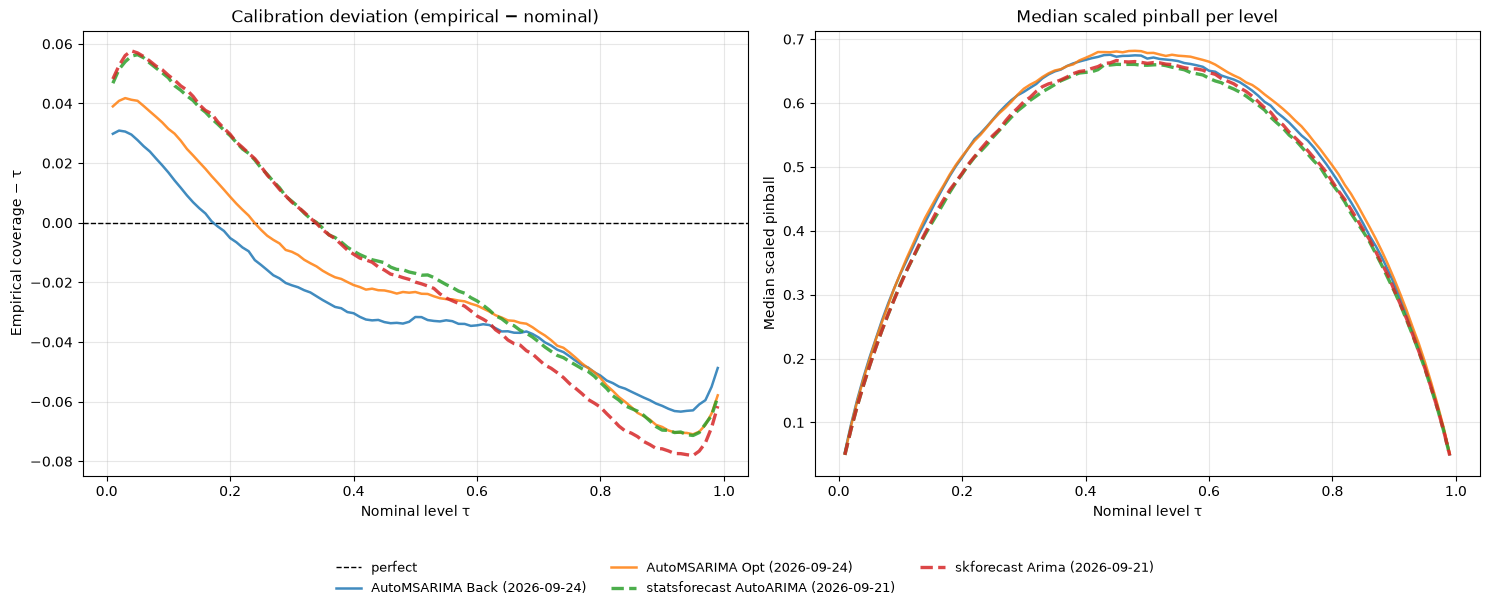

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].axhline(0.0, color="k", ls="--", lw=1, label="perfect")
for name in COMPARED:
    pin, cov = DIST[name][:, :, 0], DIST[name][:, :, 1]
    is_smooth = name in SMOOTH
    style = dict(lw=1.8 if is_smooth else 2.4, ls="-" if is_smooth else "--",
                 alpha=0.85, label=f"{name} ({SOURCE[name]})")
    ax[0].plot(LEVELS, np.nanmean(cov, axis=0) - LEVELS, **style)
    ax[1].plot(LEVELS, np.nanmedian(pin, axis=0), **style)

ax[0].set(title="Calibration deviation (empirical − nominal)",
          xlabel="Nominal level τ", ylabel="Empirical coverage − τ")
ax[1].set(title="Median scaled pinball per level",
          xlabel="Nominal level τ", ylabel="Median scaled pinball")
for a in ax:
    a.grid(alpha=0.3)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

## Change against the previous smooth run

The saved full-roster array still holds the `AutoMSARIMA` rows as they were
before the backcasting rewrite, so the two can be read side by side on exactly
the same series.

In [9]:
rows = []
for name in SMOOTH:
    j = saved["names"].index(name)
    before, after = saved["point"][j], POINT[name]
    before_pin = np.nanmean(saved["dist"][j][:, :, 0], axis=1)
    after_pin = np.nanmean(DIST[name][:, :, 0], axis=1)
    rows.append({
        "Method": name,
        "Med RMSSE before": np.nanmedian(before[:, 0]),
        "Med RMSSE after": np.nanmedian(after[:, 0]),
        "Mean RMSSE before": np.nanmean(before[:, 0]),
        "Mean RMSSE after": np.nanmean(after[:, 0]),
        "Med pinball before": np.nanmedian(before_pin),
        "Med pinball after": np.nanmedian(after_pin),
        "Mean time before": np.nanmean(before[:, 1]),
        "Mean time after": np.nanmean(after[:, 1]),
        "Series changed": int(np.sum(~np.isclose(before[:, 0], after[:, 0], equal_nan=True))),
    })
frame = pd.DataFrame(rows)
print(f"\nbefore = {saved['label']}   after = {rerun['label']}")
print(frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


before = 2026-09-21   after = 2026-09-24
          Method  Med RMSSE before  Med RMSSE after  Mean RMSSE before  Mean RMSSE after  Med pinball before  Med pinball after  Mean time before  Mean time after  Series changed
AutoMSARIMA Back            1.1828           1.2021             2.0049            2.0343              0.4956             0.5050            0.3346           0.2833            3206
 AutoMSARIMA Opt            1.2155           1.2155             2.0323            2.0323              0.5083             0.5083            1.5962           1.1959               0


## The excluded implementations, quantified

Both were measured in the saved full-roster run, so the exclusions rest on
numbers rather than on assertion. Neither was rerun: neither package changed.

In [10]:
reference = np.nanmean(POINT["AutoMSARIMA Back"][:, 1])

rows = []
for name in COMPARED + EXCLUDED:
    point = POINT[name]
    pin_series = np.nanmean(DIST[name][:, :, 0], axis=1)
    unscored = int(np.sum(np.isnan(point[:, 0])))
    timeouts = int(np.nansum(point[:, 2]))
    rows.append({
        "Method": name,
        "Status": "compared" if name in COMPARED else "excluded",
        "Source": SOURCE[name],
        "Errors": unscored - timeouts,
        "Timeouts": timeouts,
        "Med RMSSE": np.nanmedian(point[:, 0]),
        "Mean Time (s)": np.nanmean(point[:, 1]),
        "x AutoMSARIMA Back": np.nanmean(point[:, 1]) / reference,
        "CPU hours": np.nansum(point[:, 1]) / 3600,
        "Series with quantiles": int(np.sum(np.isfinite(pin_series))),
    })

excluded_summary = pd.DataFrame(rows)
print("\n" + "=" * 132)
print("WHY THE EXCLUDED ROWS ARE EXCLUDED")
print("=" * 132)
print(excluded_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nsktime: never fitted - an adapter over pmdarima, identical forecasts by construction.")


WHY THE EXCLUDED ROWS ARE EXCLUDED
                 Method   Status     Source  Errors  Timeouts  Med RMSSE  Mean Time (s)  x AutoMSARIMA Back  CPU hours  Series with quantiles
       AutoMSARIMA Back compared 2026-09-24       0         0      1.202          0.283               1.000      0.418                   5315
        AutoMSARIMA Opt compared 2026-09-24       0         0      1.215          1.196               4.221      1.766                   5315
statsforecast AutoARIMA compared 2026-09-21       0         0      1.185          1.360               4.799      2.008                   5315
       skforecast Arima compared 2026-09-21       0         0      1.191          2.099               7.409      3.099                   5315
    pmdarima auto_arima excluded 2026-09-21      42        24      1.223          9.464              33.405     13.863                   5249
         aeon AutoARIMA excluded 2026-09-21       0         0      1.495          0.044               0.157     

/tmp/ipykernel_52994/1450370895.py:6: RuntimeWarning: Mean of empty slice
  pin_series = np.nanmean(DIST[name][:, :, 0], axis=1)
